# 110. Malware Detection - binary classification

필요한 라이브러리를 import 합니다. TensorFlow/Keras를 사용하여 신경망 모델을 구축하고, sklearn을 사용하여 데이터 전처리를 수행합니다.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import seaborn as sns

Malware 데이터셋을 로드합니다. 이 데이터는 악성코드와 정상 파일을 구분하는 이진 분류 문제입니다.


In [2]:
df = pd.read_csv('malware.csv', index_col=0)
df.head()

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
65416,VirusShare_3ede9b62781398a2e39a0f6af9356a54,3ede9b62781398a2e39a0f6af9356a54,332,224,258,10,0,117760,392192,0,...,5,3.425849,2.458492,4.035538,3146.400000,48,9640,72,15,0
23220,fxsocm.dll,9a0959a682d8eba06d0bd181c49ee2a8,332,224,8462,7,10,112640,29696,0,...,8,3.911994,2.669737,5.335373,1222.750000,164,4889,72,16,1
118017,VirusShare_abe7101746242c922a539ba461db4e38,abe7101746242c922a539ba461db4e38,332,224,258,10,0,119808,385024,0,...,6,3.776760,2.458492,5.317552,2740.166667,48,9640,72,15,0
69842,VirusShare_64a1247fc96d5bc2994ef89ca09adee8,64a1247fc96d5bc2994ef89ca09adee8,332,224,258,10,0,120320,385024,0,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
22165,asferror.dll,ebc23440aa9cc4f08241d35147c1d5b5,332,224,8462,7,10,0,7168,0,...,2,3.488703,3.471506,3.505901,3050.000000,888,5212,0,16,1


데이터의 마지막 5개 행을 확인합니다.

In [3]:
df.tail()

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
130617,VirusShare_8e8aff35dc7a3719be3834ba1ab76a37,8e8aff35dc7a3719be3834ba1ab76a37,332,224,258,9,0,102400,599040,0,...,7,4.143516,2.623078,5.916356,81061.000000,62,535040,72,0,0
42632,VirusShare_c3cff0c2f56839d4b54b9cc33f8ea9ad,c3cff0c2f56839d4b54b9cc33f8ea9ad,332,224,258,10,0,118784,383488,0,...,16,6.378131,2.458492,7.992688,20821.937500,48,33945,72,14,0
82334,VirusShare_223104e64eb3cfdae9dc7a068a2eb8f4,223104e64eb3cfdae9dc7a068a2eb8f4,332,224,258,10,0,120320,385024,0,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
89459,VirusShare_df1a1468dcdf897a84bc9d8d92be449f,df1a1468dcdf897a84bc9d8d92be449f,332,224,258,10,0,118784,381952,0,...,24,6.900106,2.458492,7.990487,13895.833333,48,22648,72,14,0
72062,VirusShare_dbffdb769f89325d0b0036b92ff55179,dbffdb769f89325d0b0036b92ff55179,332,224,258,8,0,7680,309760,0,...,6,3.501717,2.128508,5.155409,1314.166667,48,3752,0,23,0


데이터의 크기를 확인합니다. 행과 열의 수를 확인할 수 있습니다.

In [4]:
df.shape

(10000, 57)

타겟 변수(legitimate)의 분포를 확인합니다. 정상 파일과 악성코드의 개수를 확인할 수 있습니다.

In [5]:
df['legitimate'].value_counts()

,count
legitimate,
0,7071
1,2929


데이터의 컬럼 이름을 확인합니다.

In [6]:
df.columns

Index(['Name', 'md5', 'Machine', 'SizeOfOptionalHeader', 'Characteristics',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage',
       'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics',
       'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve',
       'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb',
       'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy',
       'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize',
       'SectionsMeanVirtualsize', 'SectionsMinVirtualsize',
       'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb',
       'Impor

모델 학습에 불필요한 컬럼을 제거합니다. Name과 md5 해시 값은 제외하고 나머지 특성만 사용합니다.
- Name : 제외
- md5 : hash value 제외

In [7]:
df = df.iloc[:, 2:]

컬럼 제거 후 데이터의 크기를 다시 확인합니다.

In [8]:
df.shape

(10000, 55)

특성과 라벨을 분리합니다. pop() 메서드를 사용하여 legitimate 컬럼을 제거하면서 동시에 y로 할당합니다.

In [9]:
y = df.pop('legitimate').values
X = df.values

특성 데이터(X)와 타겟 데이터(y)의 형태를 확인합니다.

In [10]:
X.shape, y.shape

((10000, 54), (10000,))

데이터를 훈련 세트와 테스트 세트로 분할합니다. test_size=0.2로 80%는 훈련, 20%는 테스트 데이터로 나뉩니다.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 54), (2000, 54), (8000,), (2000,))

특성 스케일링을 수행합니다. StandardScaler를 사용하여 모든 특성을 평균 0, 표준편차 1로 정규화합니다. 신경망 모델의 학습 안정성을 높입니다.

In [12]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

Sequential 모델을 생성하고 레이어를 추가합니다. 입력층(54개 특성), 은닉층 2개(32, 16 뉴런), 출력층(1개 뉴런, sigmoid 활성화 함수)으로 구성된 신경망을 만듭니다.

In [13]:
model = tf.keras.Sequential([
    Input(shape=(54,)),               # 입력층 명시 (권장 방식)
    Dense(32, activation="relu"),     # 은닉층 1
    Dense(16, activation="relu"),     # 은닉층 2
    Dense(1, activation="sigmoid")    # 출력층 (이진 분류)
])

모델의 구조를 요약하여 출력합니다. 각 레이어의 파라미터 수와 모델의 전체 구조를 확인할 수 있습니다.

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

모델을 컴파일합니다. 이진 분류 문제이므로 손실 함수는 binary_crossentropy를 사용하고, 옵티마이저는 adam을 사용합니다. 평가 지표로 accuracy를 사용합니다.

In [15]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=["accuracy"])

모델을 학습시킵니다. epochs=20으로 설정하고, validation_data로 테스트 데이터를 사용하여 검증 손실과 정확도를 모니터링합니다.

In [16]:
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8791 - loss: 0.3720 - val_accuracy: 0.9775 - val_loss: 0.0695
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9815 - loss: 0.0540 - val_accuracy: 0.9825 - val_loss: 0.0537
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9844 - loss: 0.0467 - val_accuracy: 0.9845 - val_loss: 0.0450
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9838 - loss: 0.0438 - val_accuracy: 0.9865 - val_loss: 0.0386
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9862 - loss: 0.0421 - val_accuracy: 0.9865 - val_loss: 0.0386
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0316 - val_accuracy: 0.9885 - val_loss: 0.0383
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9876 - loss: 0.0340 - val_accuracy: 0.9870 - val_loss: 0.0376
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9896 - loss: 0.0284 - val_accuracy: 0.

학습된 모델을 테스트 데이터로 평가합니다. 테스트 손실과 정확도를 확인할 수 있습니다.

In [17]:
score = model.evaluate(X_test, y_test, verbose=0)

print(model.metrics_names)
print("Test score : {:.2f}".format(score[0]))
print("Test accuracy : {:.2f}".format(score[1]))

['loss', 'compile_metrics']
Test score : 0.04
Test accuracy : 0.99


학습 과정을 시각화합니다. 훈련 데이터와 검증 데이터의 정확도와 손실을 그래프로 표시하여 모델의 학습 과정과 과적합 여부를 확인할 수 있습니다.

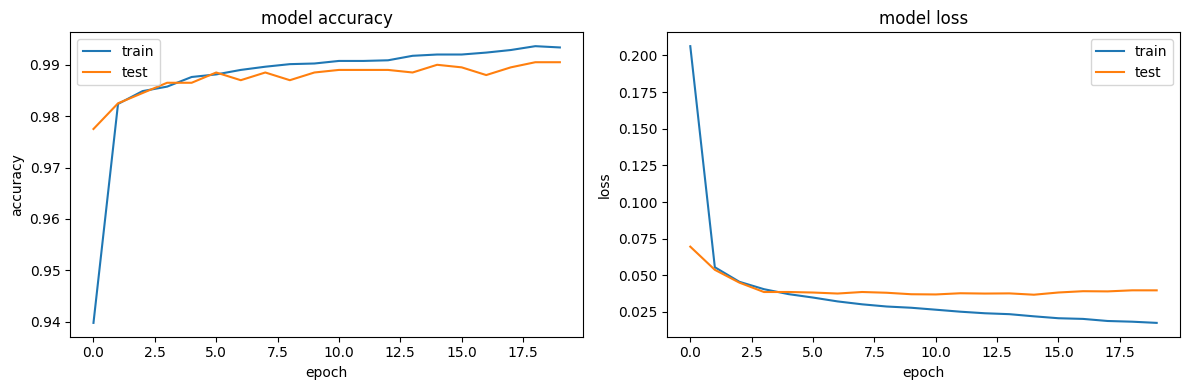

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'])
plt.tight_layout()
plt.show()

학습된 모델을 사용하여 테스트 데이터에 대한 예측을 수행합니다. 이진 분류이므로 0.5를 임계값으로 사용하여 클래스를 결정합니다.

In [20]:
y_pred = model.predict(X_test)
y_pred_class = (y_pred > 0.5).astype(int).flatten()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


혼동 행렬을 계산하고 시각화합니다. 실제 라벨과 예측 라벨의 일치 여부를 확인할 수 있습니다. 악성코드 탐지에서는 False Negative(악성코드를 놓치는 경우)가 특히 중요합니다.

Confusion Matrix:
[[ 593    8]
 [  11 1388]]


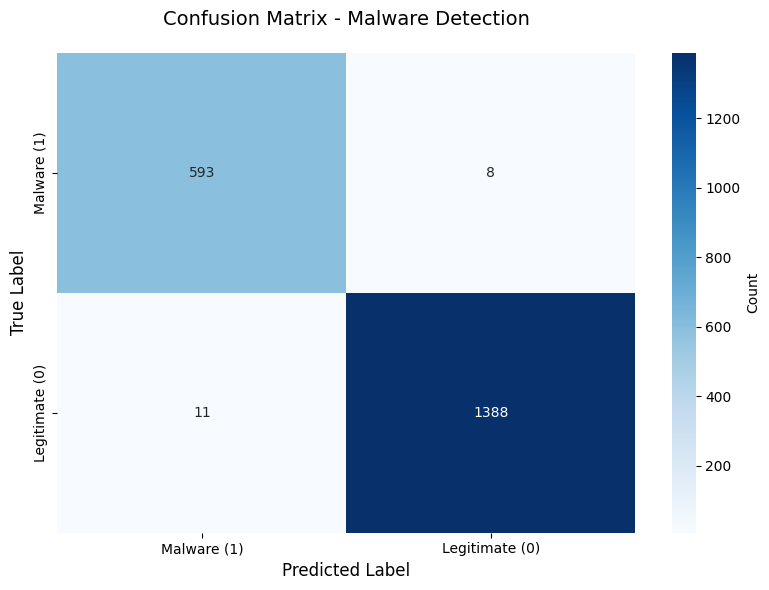


Confusion Matrix 해석:
True Positive (TP): 593 - 악성코드를 악성코드로 정확히 예측
False Positive (FP): 8 - 정상 파일을 악성코드로 잘못 예측
False Negative (FN): 11 - 악성코드를 정상 파일로 잘못 예측 (위험!)
True Negative (TN): 1388 - 정상 파일을 정상 파일로 정확히 예측


In [21]:
cm = confusion_matrix(y_test, y_pred_class, labels=[1, 0])

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 xticklabels=['Malware (1)', 'Legitimate (0)'],
                 yticklabels=['Malware (1)', 'Legitimate (0)'],
                 cbar_kws={'label': 'Count'})
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - Malware Detection', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# 각 셀의 의미 설명
print("\nConfusion Matrix 해석:")
print(f"True Positive (TP): {cm[0,0]} - 악성코드를 악성코드로 정확히 예측")
print(f"False Positive (FP): {cm[0,1]} - 정상 파일을 악성코드로 잘못 예측")
print(f"False Negative (FN): {cm[1,0]} - 악성코드를 정상 파일로 잘못 예측 (위험!)")
print(f"True Negative (TN): {cm[1,1]} - 정상 파일을 정상 파일로 정확히 예측")

정확도, 정밀도, 재현율, F1 점수를 계산하여 모델의 성능을 종합적으로 평가합니다.

In [22]:
print("\n평가 지표:")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_class)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_class, zero_division=0)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_class, zero_division=0)))
print("F1 Score: {:.4f}".format(f1_score(y_test, y_pred_class, zero_division=0)))


평가 지표:
Accuracy: 0.9905
Precision: 0.9818
Recall: 0.9867
F1 Score: 0.9842
